<a href="https://colab.research.google.com/github/Aldiss1/MPPM_Aldi/blob/main/JS04/JS04-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
# Mengimpor library
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [44]:
# Mengimpor dataset
dataset = pd.read_csv('Posisi_gaji.csv')
X = dataset.iloc[:, 1:2].values   # Fitur: tingkat posisi (2D)
y = dataset.iloc[:, 2].values     # Target: gaji (1D)

In [45]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y.reshape(-1, 1))   # scaler membutuhkan input 2D

In [46]:
# Fitting SVR ke dataset
from sklearn.svm import SVR

regressor = SVR(kernel='rbf')
regressor.fit(X, y.ravel())

SVR()

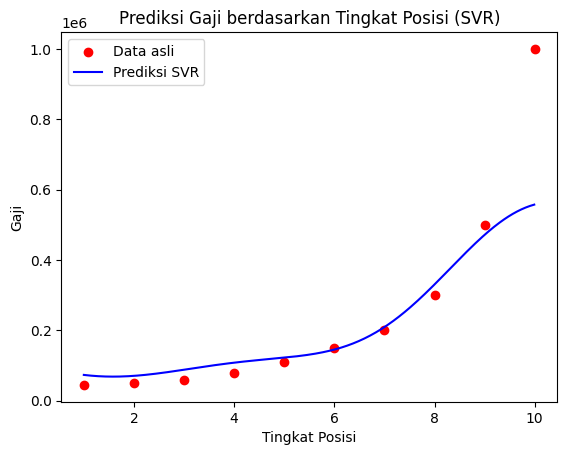

In [47]:
# Visualisasi hasil SVR (kurva halus, skala asli)
X_grid = np.arange(X.min(), X.max(), 0.01).reshape(-1, 1)

plt.scatter(sc_X.inverse_transform(X),
            sc_y.inverse_transform(y),
            color='red', label='Data asli')
plt.plot(sc_X.inverse_transform(X_grid),
         sc_y.inverse_transform(regressor.predict(X_grid).reshape(-1, 1)),
         color='blue', label='Prediksi SVR')
plt.title('Prediksi Gaji berdasarkan Tingkat Posisi (SVR)')
plt.xlabel('Tingkat Posisi')
plt.ylabel('Gaji')
plt.legend()
plt.show()

In [48]:
# Prediksi hasil
tingkat_posisi_prediksi = np.array([[6.5]])
tingkat_posisi_prediksi = sc_X.transform(tingkat_posisi_prediksi)
gaji_prediksi = regressor.predict(tingkat_posisi_prediksi)
gaji_prediksi = sc_y.inverse_transform(gaji_prediksi.reshape(-1, 1))

In [49]:
# Menampilkan hasil prediksi
print("Prediksi Gaji untuk Tingkat Posisi 6.5:", gaji_prediksi[0])

Prediksi Gaji untuk Tingkat Posisi 6.5: [170370.0204065]


In [50]:
# Evaluasi model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_actual = y.ravel()
y_pred = regressor.predict(X)

mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_actual, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)

MAE: 0.22299274095734414
MSE: 0.24839989293792014
RMSE: 0.4983973243687411
R-squared: 0.7516001070620798


In [51]:
y_actual_asli = sc_y.inverse_transform(y).ravel()
y_pred_asli = sc_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()

print("MAE (asli):", mean_absolute_error(y_actual_asli, y_pred_asli))
print("RMSE (asli):", np.sqrt(mean_squared_error(y_actual_asli, y_pred_asli)))

MAE (asli): 63332.39208968966
RMSE (asli): 141550.32413997417
